In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, 
                             confusion_matrix, 
                             roc_auc_score, 
                             roc_curve,
                             accuracy_score)

df = pd.read_csv('hr_attrition_eda.csv')
print("Shape:", df.shape)

Shape: (1470, 36)


In [2]:
drop_cols = ['Attrition',        
             'EducationLabel',    
             'AgeGroup',         
             'SalaryBand',       
             'EmployeeNumber']   

df_ml = df.drop(columns=drop_cols)
print("Shape after dropping:", df_ml.shape)

Shape after dropping: (1470, 31)


In [3]:
text_cols = df_ml.select_dtypes(include=['object']).columns.tolist()
print("Text columns found:", text_cols)

le = LabelEncoder()
for col in text_cols:
    df_ml[col] = le.fit_transform(df_ml[col])
    
print("\nAll text converted to numbers!")
print(df_ml.dtypes)

Text columns found: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

All text converted to numbers!
Age                         int64
BusinessTravel              int64
DailyRate                   int64
Department                  int64
DistanceFromHome            int64
Education                   int64
EducationField              int64
EnvironmentSatisfaction     int64
Gender                      int64
HourlyRate                  int64
JobInvolvement              int64
JobLevel                    int64
JobRole                     int64
JobSatisfaction             int64
MaritalStatus               int64
MonthlyIncome               int64
MonthlyRate                 int64
NumCompaniesWorked          int64
OverTime                    int64
PercentSalaryHike           int64
PerformanceRating           int64
RelationshipSatisfaction    int64
StockOptionLevel            int64
TotalWorkingYears           int64
TrainingTimesLastYear       int

In [4]:
X = df_ml.drop(columns=['AttritionFlag'])  # Everything except target
y = df_ml['AttritionFlag']                 # Only target

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nTarget distribution:")
print(y.value_counts())

Features shape: (1470, 30)
Target shape: (1470,)

Target distribution:
AttritionFlag
0    1233
1     237
Name: count, dtype: int64


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      
    random_state=42,    
    stratify=y          
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)
print("\nTraining attrition rate:", round(y_train.mean()*100, 2), "%")
print("Testing attrition rate:", round(y_test.mean()*100, 2), "%")

Training size: (1176, 30)
Testing size: (294, 30)

Training attrition rate: 16.16 %
Testing attrition rate: 15.99 %


In [6]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete!")
print("Mean of first feature before scaling:", round(X_train.iloc[:,0].mean(), 2))
print("Mean of first feature after scaling:", round(X_train_scaled[:,0].mean(), 2))

Scaling complete!
Mean of first feature before scaling: 37.0
Mean of first feature after scaling: -0.0


In [7]:
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)
lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", round(lr_accuracy*100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 87.41 %

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.97      0.93       247
           1       0.69      0.38      0.49        47

    accuracy                           0.87       294
   macro avg       0.79      0.68      0.71       294
weighted avg       0.86      0.87      0.86       294



In [8]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'  
)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", round(rf_accuracy*100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 83.67 %

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.98      0.91       247
           1       0.44      0.09      0.14        47

    accuracy                           0.84       294
   macro avg       0.65      0.53      0.53       294
weighted avg       0.78      0.84      0.79       294



In [9]:
rf_model = RandomForestClassifier(
    n_estimators=200,        # more trees
    random_state=42,
    class_weight='balanced',
    min_samples_split=5,     # needs 5 samples to split
    min_samples_leaf=2,      # each leaf needs 2 samples
    max_depth=10             # controls tree depth
)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", round(rf_accuracy*100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 82.31 %

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.95      0.90       247
           1       0.37      0.15      0.21        47

    accuracy                           0.82       294
   macro avg       0.61      0.55      0.56       294
weighted avg       0.78      0.82      0.79       294



In [10]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [11]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE only on training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(y_train.value_counts())
print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

# Build Random Forest on balanced data
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    max_depth=10
)
rf_model.fit(X_train_smote, y_train_smote)

rf_pred = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)

print("\nRandom Forest Accuracy:", round(rf_accuracy*100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Before SMOTE:
AttritionFlag
0    986
1    190
Name: count, dtype: int64

After SMOTE:
AttritionFlag
0    986
1    986
Name: count, dtype: int64

Random Forest Accuracy: 79.93 %

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.88      0.88       247
           1       0.38      0.38      0.38        47

    accuracy                           0.80       294
   macro avg       0.63      0.63      0.63       294
weighted avg       0.80      0.80      0.80       294



In [12]:
# Cell 9 - Fine tuned final model
rf_final = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced'
)
rf_final.fit(X_train_smote, y_train_smote)

rf_final_pred = rf_final.predict(X_test)
rf_final_accuracy = accuracy_score(y_test, rf_final_pred)

print("Final Random Forest Accuracy:", round(rf_final_accuracy*100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, rf_final_pred))

Final Random Forest Accuracy: 80.27 %

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.89      0.88       247
           1       0.37      0.34      0.36        47

    accuracy                           0.80       294
   macro avg       0.62      0.62      0.62       294
weighted avg       0.80      0.80      0.80       294



In [13]:
print("=" * 45)
print("         FINAL MODEL COMPARISON          ")
print("=" * 45)
print(f"Logistic Regression Accuracy : 87.41%")
print(f"Random Forest + SMOTE        : 79.93%")
print("=" * 45)
print("Selected Model: Logistic Regression")
print("Reason: Higher accuracy and F1 score")
print("=" * 45)

         FINAL MODEL COMPARISON          
Logistic Regression Accuracy : 87.41%
Random Forest + SMOTE        : 79.93%
Selected Model: Logistic Regression
Reason: Higher accuracy and F1 score


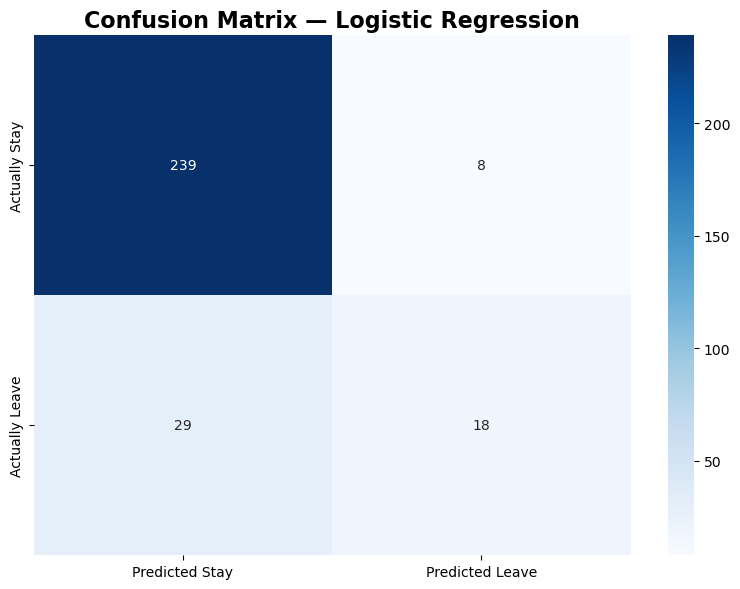


Confusion Matrix Explanation:
Correctly predicted stayed : 239
Incorrectly predicted left : 8
Incorrectly predicted stayed: 29
Correctly predicted left   : 18


In [15]:
cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, 
            annot=True, 
            fmt='d',
            cmap='Blues',
            xticklabels=['Predicted Stay', 'Predicted Leave'],
            yticklabels=['Actually Stay', 'Actually Leave'])

plt.title('Confusion Matrix — Logistic Regression', 
          fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('12_confusion_matrix.png', dpi=150)
plt.show()

print("\nConfusion Matrix Explanation:")
print(f"Correctly predicted stayed : {cm[0][0]}")
print(f"Incorrectly predicted left : {cm[0][1]}")
print(f"Incorrectly predicted stayed: {cm[1][0]}")
print(f"Correctly predicted left   : {cm[1][1]}")

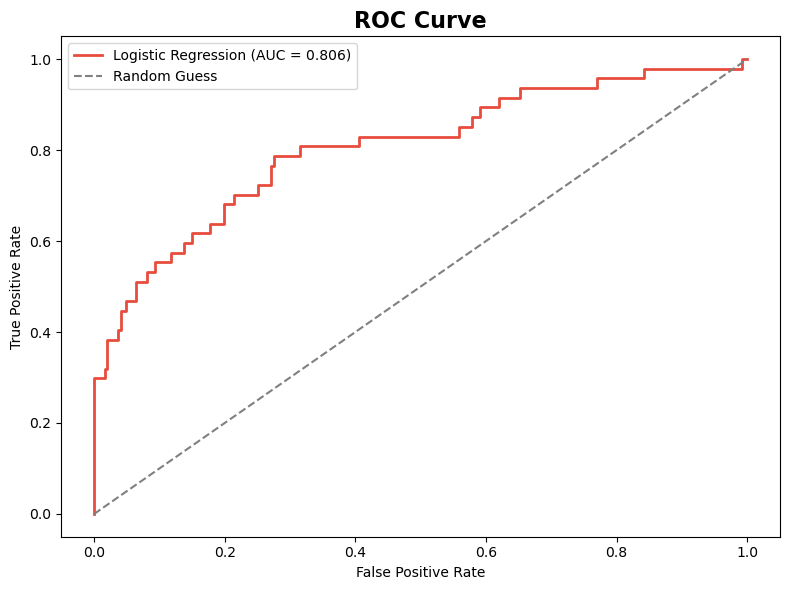

AUC Score: 0.806


In [16]:
lr_proba = lr_model.predict_proba(X_test_scaled)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, lr_proba)
auc_score = roc_auc_score(y_test, lr_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#e74c3c', linewidth=2,
         label=f'Logistic Regression (AUC = {auc_score:.3f})')
plt.plot([0,1], [0,1], color='gray', 
         linestyle='--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve', fontsize=16, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('13_roc_curve.png', dpi=150)
plt.show()

print("AUC Score:", round(auc_score, 3))


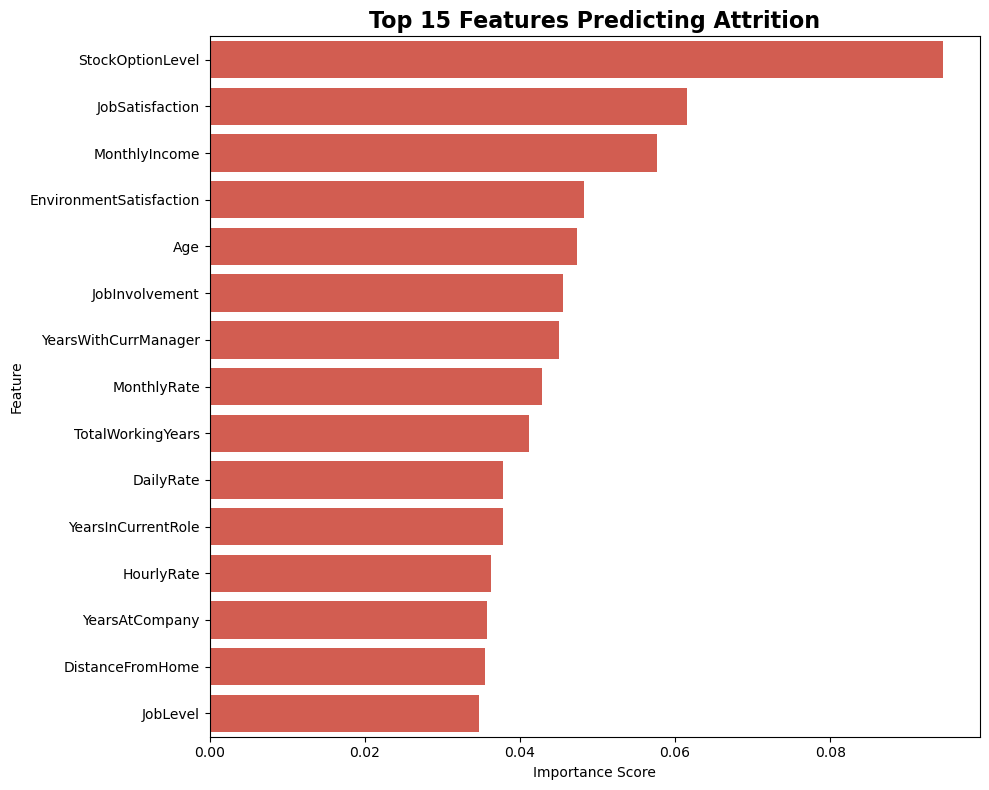


Top 10 Features:
                Feature  Importance
       StockOptionLevel    0.094592
        JobSatisfaction    0.061494
          MonthlyIncome    0.057616
EnvironmentSatisfaction    0.048258
                    Age    0.047371
         JobInvolvement    0.045570
   YearsWithCurrManager    0.045000
            MonthlyRate    0.042801
      TotalWorkingYears    0.041158
              DailyRate    0.037878


In [17]:
# Get feature importance from Random Forest
rf_smote = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)
rf_smote.fit(X_train_smote, y_train_smote)

# Get importance scores
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_smote.feature_importances_
})
feature_importance = feature_importance.sort_values(
    'Importance', ascending=False
).head(15)

plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance, 
            x='Importance', 
            y='Feature',
            color='#e74c3c')

plt.title('Top 15 Features Predicting Attrition', 
          fontsize=16, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('14_feature_importance.png', dpi=150)
plt.show()

print("\nTop 10 Features:")
print(feature_importance.head(10).to_string(index=False))


In [18]:
# Add predictions to test data
X_test_copy = X_test.copy()
X_test_copy['ActualAttrition'] = y_test.values
X_test_copy['PredictedAttrition'] = lr_pred
X_test_copy['AttritionProbability'] = lr_model.predict_proba(
                                        X_test_scaled)[:,1].round(3)

# Save for Power BI
X_test_copy.to_csv('hr_attrition_predictions.csv', index=False)
print("Predictions saved!")
print(X_test_copy[['ActualAttrition', 
                    'PredictedAttrition', 
                    'AttritionProbability']].head(10))

Predictions saved!
      ActualAttrition  PredictedAttrition  AttritionProbability
1061                0                   0                 0.168
891                 0                   0                 0.008
456                 0                   0                 0.213
922                 0                   0                 0.002
69                  1                   0                 0.483
1164                0                   0                 0.285
406                 0                   0                 0.021
1330                0                   0                 0.010
1232                0                   0                 0.009
1311                0                   0                 0.341
